In [2]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions langchain-text-splitters

In [3]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [4]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.3-70b-versatile")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="qwen/qwen3-next-80b-a3b-instruct:free",
#     temperature=0.8,
# )

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")




modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
import warnings

warnings.filterwarnings("ignore")

In [8]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [9]:
llm.invoke("Hello how are you?")

AIMessage(content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 40, 'total_tokens': 88, 'completion_time': 0.099184439, 'completion_tokens_details': None, 'prompt_time': 0.000950392, 'prompt_tokens_details': None, 'queue_time': 0.053880407, 'total_time': 0.100134831}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e753a-2e58-7b41-ae50-4c291b71a28f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 48, 'total_tokens': 88})

In [10]:
url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [11]:
WebBaseLoader(url).load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [12]:
WebBaseLoader(url).load()[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [13]:
WebBaseLoader(url).load()[0].metadata["description"]

'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model 

In [14]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [15]:
docs = [WebBaseLoader(url).load() for url in urls]

In [16]:
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [22]:
docs_list = [item for sublist in docs for item in sublist]

In [23]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=25)

In [24]:
doc_splits = text_splitter.split_documents(docs_list)

In [25]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [26]:
vectorestore = Chroma.from_documents(
    documents = doc_splits,
    collection_name="rag-chrome",
    embedding=embeddings,
)

In [27]:
retriever = vectorestore.as_retriever()

In [28]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.",
)

In [29]:
tools = [retriever_tool]

In [30]:
retrieve = ToolNode([retriever_tool])

Certainly! Let's break down the code:

### **Code Breakdown:**

```python
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
```

This code defines a class `AgentState` that is a **`TypedDict`**, which is a special kind of dictionary with fixed keys and value types, used to provide better type safety and autocompletion in Python.

Here’s a breakdown of each part:

---

### **1. `AgentState(TypedDict)`**
- **`TypedDict`**: This is a special class provided by `typing` that allows you to define dictionaries where each key has a fixed type. The dictionary keys are usually predefined, and each key must have a specified type.

  - `AgentState` here is a subclass of `TypedDict`, meaning `AgentState` will represent a dictionary where the types of its values are enforced.

  - Example:
    ```python
    agent_state = AgentState(messages=["Message 1", "Message 2"])  # This would be valid.
    ```

---

### **2. `messages: Annotated[Sequence[BaseMessage], add_messages]`**
- **`messages`**: This is a key in the `AgentState` dictionary. It holds a sequence (like a list or tuple) of `BaseMessage` objects.
  
- **`Annotated[...]`**: `Annotated` is used to attach additional metadata or annotations to the type. It’s a way to add extra information to the type system without affecting the actual type. In this case, it provides metadata for the `messages` field.

  - The **`Annotated`** wrapper allows you to define a type and also include additional information that might be used by tools like static analyzers or for other purposes like validation.

- **`Sequence[BaseMessage]`**: This indicates that `messages` should be a sequence (e.g., a list or tuple) of `BaseMessage` objects.

  - **`BaseMessage`** is likely a class that represents a message in the context of your program. It could have fields like `content`, `sender`, `timestamp`, etc.
  
- **`add_messages`**: This is a special annotation (or metadata) that likely refers to some function or constant that’s being added as additional context. The specific role of `add_messages` will depend on how it's defined elsewhere in the codebase.

  - **`add_messages`** could be a function, validator, or modifier that helps manage or process the messages in some way, but it's not directly modifying the type of `messages`. It's simply metadata for the type checker or other parts of the system.

  - For example, if `add_messages` were a function, it could be used in a custom decorator, validation system, or simply as an indication of how to handle messages.

---

### **Putting It All Together:**

- **`AgentState`** is a dictionary where one of the keys, `messages`, is specifically typed to be a **sequence of `BaseMessage`** objects. The sequence is annotated with **`add_messages`**, which provides additional metadata but doesn’t affect the type directly.
  
- **Example of `AgentState` usage:**

```python
from typing import TypedDict, Sequence
from typing_extensions import Annotated

class BaseMessage:
    def __init__(self, content: str):
        self.content = content

# Defining the `AgentState` TypedDict
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], "add_messages"]

# Example usage
message1 = BaseMessage("Hello, world!")
message2 = BaseMessage("How are you?")
state = AgentState(messages=[message1, message2])

print(state)
```

In the above code:
- `AgentState` is a dictionary with a `messages` field that is a sequence of `BaseMessage` objects.
- `add_messages` is metadata associated with the `messages` field, which can help guide the usage or interpretation of the data.

---

### **Summary:**
- `AgentState` is a dictionary where the `messages` key holds a sequence of `BaseMessage` objects.
- `Annotated[Sequence[BaseMessage], add_messages]` means that `messages` is a sequence of `BaseMessage` objects with additional metadata (`add_messages`).
- The annotation `add_messages` provides extra context or metadata that doesn't alter the type directly but can be used for purposes like validation or other system-specific behavior.

Let me know if you'd like further clarification on any part of this! 😊

In [31]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [32]:
def ai_assistant(state: AgentState):
  print("---CALL AGENT---")
  messages = state["messages"]


  if len(messages) > 1:
    last_message = messages[-1]
    question = last_message.content
    prompt = PromptTemplate.from_template(
        template="""You are a helpful assistant whatever question has been asked to find out that in the given question and answer.
                        Here is the question:{question}
                        """,
                        input_variables=["question"]
    )

    chain = prompt | llm

    response = chain.invoke({"question": question})
    return {"messages": [response]}

  else:
    llm_with_tool = llm.bind_tools(tools)
    response = llm_with_tool.invoke(messages)
    #response.handle_query(messages)
    return {"messages": [response]}


In [33]:
class grade(BaseModel):
  binary_score: str = Field(description="Relevance score yes or no")

In [35]:
def grade_documents(state: AgentState):
  llm_with_structure_op = llm.with_structured_output(grade)

  prompt = PromptTemplate(
      template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant.
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables = ["context", "question"]
                )

  chain = prompt | llm_with_structure_op

  messages = state["messages"]
  last_message = messages[-1]
  question = messages[0].content
  docs = last_message.content
  scored_result = chain.invoke({"question": question, "context": docs})
  score = scored_result.binary_score

  if score == "yes":
    print("---DECISION: DOCS RELEVANT---")
    return "generator" #this should be a node name

  else:
    print("---DECISION: DOCS NOT RELEVANT---")
    return "rewriter" #this should be a node name

In [38]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)
prompt.pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [39]:
def generate(state: AgentState):
  print("---GENERATE---")
  messages = state["messages"]

  question = messages[0].content

  last_message = messages[-1]
  docs = last_message.content

  from langsmith import Client

  client = Client()
  prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

  rag_chain = prompt | llm

  response = rag_chain.invoke({"context": docs, "question": question})
  print(f"this is my response:{response}")

  return {"messages":[response]}


In [40]:
from langchain_core.messages import HumanMessage
def rewrite(state: AgentState):
  print("---TRANSFORM QUERY---")
  messages = state["messages"]
  question = messages[0].content

  message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning.
                    Here is the initial question: {question}
                    Formulate an improved question: """)
            ]
  response = llm.invoke(message)
  return {"messages": [response]}

In [58]:
workflow = StateGraph(AgentState)
workflow.add_node("My_Ai_Assistant", ai_assistant)
workflow.add_node("Vector_Retriever", retrieve)
workflow.add_node("Output_Generator", generate)
workflow.add_node("Query_Rewriter", rewrite)


In [59]:
workflow.add_edge(START, "My_Ai_Assistant")

In [60]:
workflow.add_conditional_edges(
    "My_Ai_Assistant",
    tools_condition,
    {
        "tools": "Vector_Retriever",
        END: END,
    }
)

In [61]:
workflow.add_conditional_edges(
    "Vector_Retriever",
    grade_documents,
    {
        "generator": "Output_Generator",
        "rewriter": "Query_Rewriter",
    }
)

In [62]:
workflow.add_edge("Output_Generator", END)

In [63]:
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")

In [64]:
app = workflow.compile()

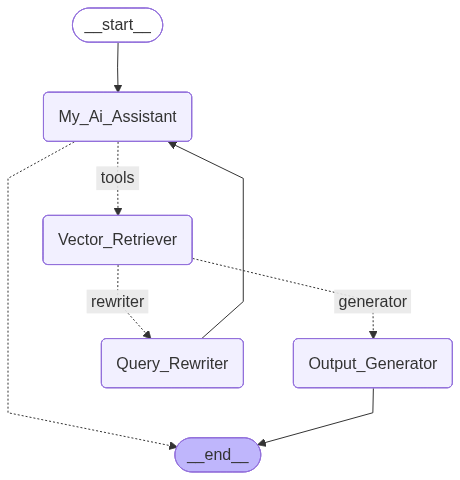

In [65]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [66]:
app.invoke({"messages":["What is a Autonomous Agent?"]})


---CALL AGENT---


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='3babd4e1-684f-4d47-aa6a-c7f5412f2981'),
  AIMessage(content='An autonomous agent is a system or entity that can operate independently, making decisions and taking actions without direct human intervention. Autonomous agents can be found in various fields, including artificial intelligence, robotics, and economics. They are typically characterized by their ability to perceive their environment, reason about their situation, and adapt to changes.\n\nAutonomous agents can be classified into different types, such as:\n\n1. Simple reflex agents: These agents react to the current state of the environment without considering future consequences.\n2. Model-based reflex agents: These agents maintain an internal model of the environment and use it to make decisions.\n3. Goal-based agents: These agents have specific goals and use planning and decision-making to achieve them.\n4. Utili

In [67]:
app.invoke({"messages":["what is a prompt engineering please explain me in terms of agents and langchain?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='what is a prompt engineering please explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='35c3169f-348a-43ae-a7ee-b8b0aaca0ada'),
  AIMessage(content="Prompt engineering refers to the process of designing and optimizing text prompts that are used to interact with language models (LLMs) or other artificial intelligence (AI) systems, such as agents. The goal of prompt engineering is to craft prompts that elicit specific, accurate, and relevant responses from the model.\n\nIn the context of LangChain, prompt engineering is crucial for effective communication between humans and LLM agents. LangChain is a framework that enables the development of applications that utilize LLMs as core components. By using well-designed prompts, developers can create more efficient, effective, and user-friendly interactions between humans and LLM agents.\n\nThere are several key aspects of prompt engineering in the context of LangCh

In [68]:
app.invoke({"messages":["what is the capital of China?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='what is the capital of China?', additional_kwargs={}, response_metadata={}, id='9f6fb21e-6a18-4bae-923a-051df586ac37'),
  AIMessage(content='The capital of China is Beijing.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 393, 'total_tokens': 401, 'completion_time': 0.019255809, 'completion_tokens_details': None, 'prompt_time': 0.032999308, 'prompt_tokens_details': None, 'queue_time': 0.161053621, 'total_time': 0.052255117}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7548-93bc-7742-b9b7-f75f75ddaa32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 393, 'output_tokens': 8, 'total_tokens': 401})]}